In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
Train_val= pd.read_csv("datasets/train.csv")
X_test=pd.read_csv("datasets/test.csv")


# Exploratory data analysis

In [3]:
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
categorical_features = ["HomePlanet", "Deck", "Side", "Destination"]
other_features = ["CryoSleep", "Cabin_num", "Age","VIP"]
Train_val.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
Train_val.shape[0]

8693

In [5]:
Train_val.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
Train_val.describe(include='object')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Gollux Reedall
freq,1,4602,5439,8,5915,8291,2


In [7]:
#There are 20 people who have their names listed more than once. All of them have their names listed exactly twice.
#They have different passengerids, and some difference in the values of the features so it is not duplicates
# It seems like they have been on the ship before
(Train_val["Name"].value_counts()==2).sum()


np.int64(20)

In [8]:
Train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


#### Amount of missing data

In [9]:
Train_val.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
Train_val.isna().sum()/Train_val.shape[0]*100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

In [11]:
for col in Train_val.select_dtypes(include='object').columns:
    print(Train_val[col].value_counts())

PassengerId
0001_01    1
6136_01    1
6141_01    1
6139_06    1
6139_05    1
          ..
3126_01    1
3124_03    1
3124_02    1
3124_01    1
9280_02    1
Name: count, Length: 8693, dtype: int64
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
CryoSleep
False    5439
True     3037
Name: count, dtype: int64
Cabin
G/734/S     8
G/109/P     7
B/201/P     7
G/1368/P    7
G/981/S     7
           ..
G/556/P     1
E/231/S     1
G/545/S     1
G/543/S     1
F/947/P     1
Name: count, Length: 6560, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
VIP
False    8291
True      199
Name: count, dtype: int64
Name
Gollux Reedall        2
Elaney Webstephrey    2
Grake Porki           2
Sus Coolez            2
Apix Wala             2
                     ..
Jamela Griffy         1
Hardy Griffy          1
Salley Mckinn         1
Mall Frasp            1
Propsh Hontichre      1
Name: count, Length: 8473, d

In [12]:
Train_val.duplicated().sum()

np.int64(0)

Text(0.5, 0, 'Transported')

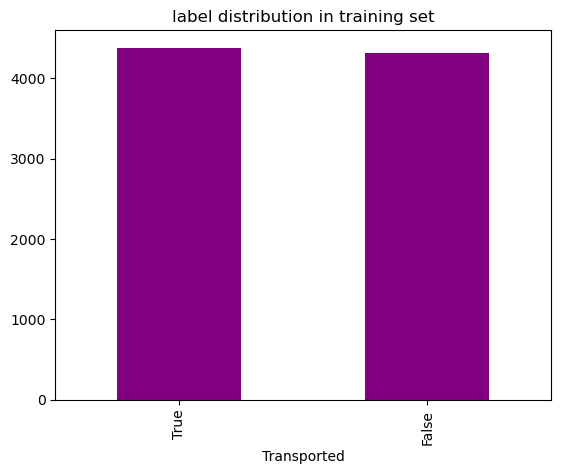

In [13]:
data_y=Train_val.Transported 
data_X=Train_val.drop("Transported", axis=1)

plt.title("label distribution in training set")
data_y.value_counts().plot.bar(color="purple")
plt.xlabel("Transported")


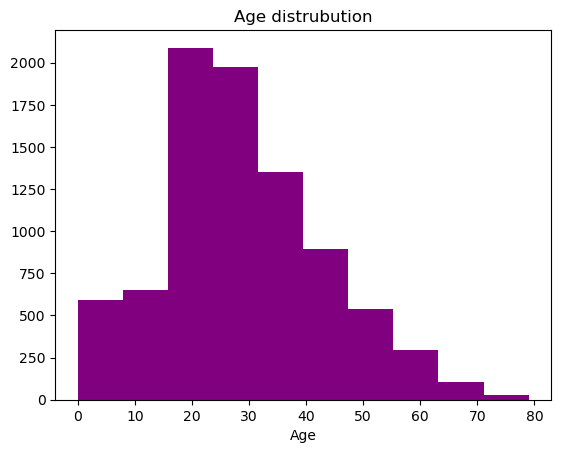

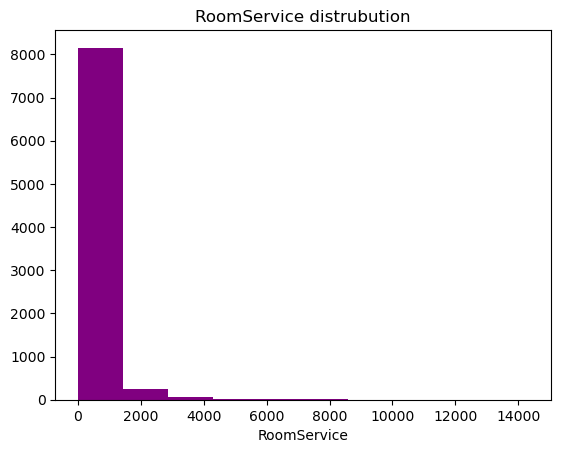

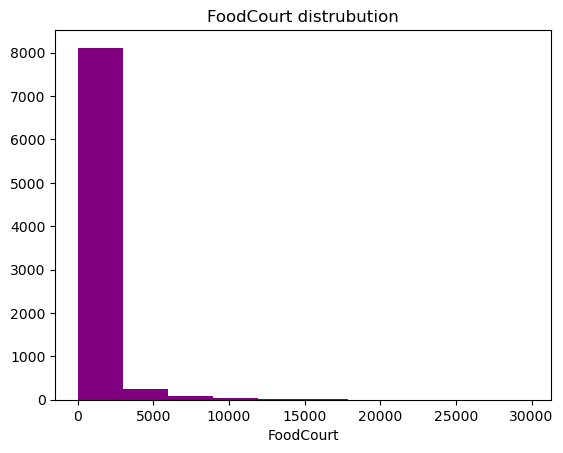

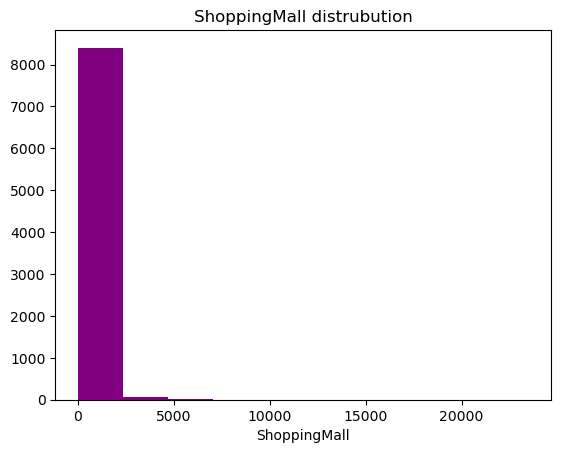

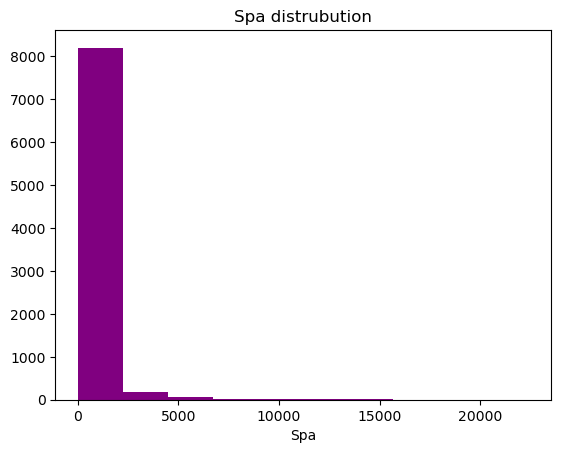

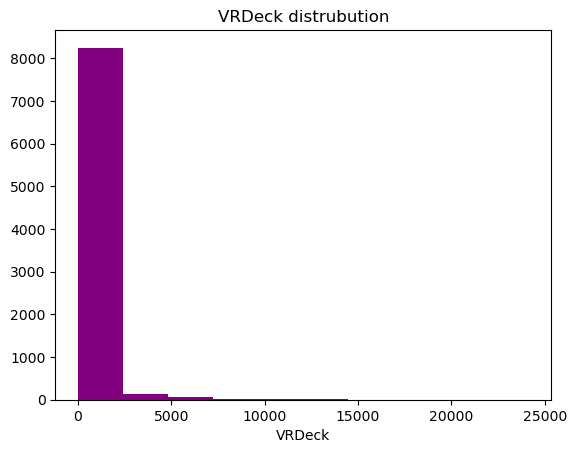

In [14]:
for col in Train_val.select_dtypes(exclude=['object', 'bool']).columns:
    plt.figure()
    plt.title(f"{col} distrubution")
    plt.hist(Train_val[col],color="purple")
    plt.xlabel(col)
    plt.show()
    

From these graphs we see that there are large outliers for each of the luxury services. This makes sense. Some rich people are going to spend a lot of money which will differ from what a normal person spends

# Preprocessing

### Splitting data before preprocessing

In [15]:
data=Train_val.iloc[:, :-1]
label=Train_val.iloc[:,-1]
X_train,X_val,y_train,y_val=train_test_split(data,label,test_size=0.2, random_state=42)
train=pd.concat([X_train,y_train], axis=1)
val=pd.concat([X_val,y_val], axis=1)

### New features

Added a feature "TotalSpending" which is just a sum of all numerical (amenity spending) features

Added "GroupID", which is the first part of passengerID giving groups the same ID

Added "Alone", which describes if a passenger has no other members in group

Split cabin id to room number, side, and deck

In [16]:
# Total Spending:
def new_features(data):
    data = data.copy()
    data['TotalSpending'] = data[amenities].sum(axis=1, skipna=False)

    # Passenger group + travelling alone:
    data["GroupID"] = data["PassengerId"].str.split("_").str[0]
    data["Alone"] = (data.groupby("GroupID")["PassengerId"].transform("count") == 1)

    # Split Cabin to deck, number, and side,
    data[["Deck", "Cabin_num", "Side"]] = data["Cabin"].str.split("/", expand=True)
    data['Cabin_num'] = data['Cabin_num'].astype('Int64')
    return data

train=new_features(train)
val=new_features(val)
X_test=new_features(X_test)



## Handling missing values

### Categorical

I assume that people from one family (same last name) are from the same homeplanet. I want to check if this assumption is right

In [17]:
train['LastName'] = train['Name'].str.strip().str.split().str[-1]
known_planet_mask=train["HomePlanet"].notna()
known=train.loc[known_planet_mask, ["HomePlanet", "LastName"]]

x=known.groupby("LastName")["HomePlanet"].nunique()


if (x == 1).all():
    print("Every member of the family is from one homeplanet")
    
else:
    print("Some familys have members with different homeplanets")

Every member of the family is from one homeplanet


Since my assmption was right, I will check if people with missing homeplanets are traveling with family/has family that has been on the spaceship before. If this is the case they will get the same homeplanet as the others in their family

In [18]:
def get_lastname_planet_mapping(data):
    data = data.copy()
    data['LastName'] = data['Name'].str.strip().str.split().str[-1]
    return (data.loc[data['HomePlanet'].notna(), ['LastName', 'HomePlanet']]
            .drop_duplicates(subset='LastName')
            .set_index('LastName')['HomePlanet'])

def fill_homeplanets(data, mapping):
    data = data.copy()
    data['LastName'] = data['Name'].str.strip().str.split().str[-1]
    data['HomePlanet'] = data['HomePlanet'].fillna(data['LastName'].map(mapping))
    return data

mapping=get_lastname_planet_mapping(train)

train=fill_homeplanets(train,mapping)
val=fill_homeplanets(val,mapping)
X_test=fill_homeplanets(X_test,mapping)

Remaining missing values in the homeplanet column

In [19]:
train["HomePlanet"].isna().sum()+val["HomePlanet"].isna().sum()+X_test["HomePlanet"].isna().sum()

np.int64(26)

Filling the remaining nan values with the most common homeplanet from the training dataset

In [20]:
most_common_planet_train = train['HomePlanet'].mode()[0] 

train["HomePlanet"]=train["HomePlanet"].fillna(most_common_planet_train)
val["HomePlanet"]=val["HomePlanet"].fillna(most_common_planet_train)
X_test["HomePlanet"]=X_test["HomePlanet"].fillna(most_common_planet_train)


In [21]:
#Sanity check
for name, d in [("train", train), ("val", val), ("test", X_test)]:
    nan_planets=d["HomePlanet"].isna().sum()
    print(f"{name} dataset has {nan_planets} homeplanet nan values")

train dataset has 0 homeplanet nan values
val dataset has 0 homeplanet nan values
test dataset has 0 homeplanet nan values


#### Exploring patterns in the remanining categorical features

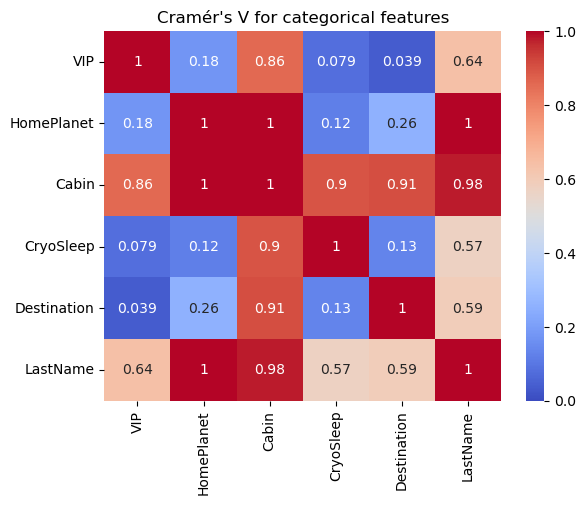

In [22]:
#I include homeplanet in case there is a relationship where we can use the known homeplanet to impute the missing value 
# of another feature
cols = ["VIP", "HomePlanet", "Cabin", "CryoSleep", "Destination", "LastName"]
v_matrix = pd.DataFrame(index=cols, columns=cols)
def cramers_v(ct):
    chi2,_,_,_=chi2_contingency(ct)
    n=ct.values.sum() 
    r, c= ct.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1
        else:
            ct = pd.crosstab(train[col1], train[col2])
            v_matrix.loc[col1, col2] = cramers_v(ct)


v_matrix = v_matrix.astype(float)


sns.heatmap(v_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér's V for categorical features")
plt.show()


Based on the heatmap, there should be a strong correlation between cabin and all the other categorical features. I want to explore these relationships and see if it is possible to use them to impute missing values

In [23]:
# first we find the cabins that are shared by a family
cabin_counts =train["Cabin"].value_counts()
multi_person_cabins = cabin_counts[cabin_counts > 2].index
df_family = train[train["Cabin"].isin(multi_person_cabins)]

# we check how many homeplanets exits within one family cabin (should be one homeplanet based on earlier discoveries)
cabin_planet_diversity = df_family.groupby("Cabin")["HomePlanet"].nunique()
print("Multi person cabins with more than one homeplanet", (cabin_planet_diversity > 1).sum())
print("Total amount of multi person cabins:", cabin_planet_diversity.count())


# Since there are three homeplanets and many unique cabins it does not help us 
unique_cabins_per_planet = df_family.groupby("HomePlanet")["Cabin"].nunique()
print("\nAmount of unique cabins per homeplanet:")
print(unique_cabins_per_planet)

Multi person cabins with more than one homeplanet 0
Total amount of multi person cabins: 299

Amount of unique cabins per homeplanet:
HomePlanet
Earth     110
Europa    137
Mars       52
Name: Cabin, dtype: int64


In [24]:
one_cabin_within_family=(df_family.groupby("LastName")["Cabin"].nunique()==1).sum() /df_family.groupby("LastName")["Cabin"].nunique().count()

print(f"Amount of familys that share one cabin : {one_cabin_within_family}")

Amount of familys that share one cabin : 0.9112271540469974


#### Filling missing False values for cryosleep:

People who are spending money are probably awake. Equally, people who are asleep are likely not spending money.

In [25]:
def filling_false_values_cryosleep(data):
    data = data.copy()
    
    mask_awake = data['TotalSpending'] > 0
    data.loc[mask_awake, 'CryoSleep'] = False
    
    mask_asleep = data['CryoSleep'] == True
    data.loc[mask_asleep, amenities] = data.loc[mask_asleep, amenities].fillna(0)
    
    return data


train  = filling_false_values_cryosleep(train)
val    = filling_false_values_cryosleep(val)
X_test = filling_false_values_cryosleep(X_test)

In [26]:
vip_cabin_count_family = (
    df_family
    .dropna(subset=["VIP"])
    .groupby("Cabin")["VIP"]
    .agg(["nunique", "count"])
    .query("count > 1")["nunique"]
)

print(f"how many percent of multi person cabins have one vip status: {(vip_cabin_count_family==1).sum()/vip_cabin_count_family.count()}")

how many percent of multi person cabins have one vip status: 0.8929765886287625


In [27]:
#checking if it is common that within a multiperson cabin the people usually go to the same destination
Destination=df_family.groupby("Cabin")["Destination"].value_counts()

print(f"How many percent of multi person cabins go to the same destination  {(Destination==1).sum() /Destination.count()}")


How many percent of multi person cabins go to the same destination  0.391713747645951


In [28]:
#last name and destination
destinations_per_lastname= df_family.groupby("LastName")["Destination"].nunique()
lastname_same_destination_p = (destinations_per_lastname == 1).mean() * 100
print(F"percent of people with the same last name that go to the same destination :{lastname_same_destination_p}")


percent of people with the same last name that go to the same destination :51.958224543080945


In [29]:
def vip_mapping(data):
    mapping={}
    for cabin_name, cabin_group in data.groupby("Cabin"):
        known_status= cabin_group["VIP"].dropna()
        if len(known_status)>0:
            mapping[cabin_name]=known_status.mode()[0]
    return mapping
def fill_vip_from_cabin(data,mapping):
    data=data.copy()
    mask=data["VIP"].isna()
    data.loc[mask,"VIP"]=data.loc[mask,"Cabin"].map(mapping)
    return data

vip_mapping=vip_mapping(train)

train  = fill_vip_from_cabin(train, vip_mapping)
val    = fill_vip_from_cabin(val,vip_mapping)
X_test = fill_vip_from_cabin(X_test,vip_mapping)

In [30]:
print(f"VIP missing after imputation: {train['VIP'].isna().sum()}")

VIP missing after imputation: 115


In [31]:
cols = ["Cabin","Deck", "Cabin_num", "Side", "CryoSleep", "Destination", "VIP", "Name"]

n_total = len(train)
n_remaining = len(train.dropna(subset=cols))
n_removed = n_total - n_remaining

print(f"Total amount of rows in the trainingdataset: {n_total}")
print(f"Rows to remove: {n_removed}")
print(f"Rows remaning: {n_remaining}")
print(f"percent to remove: {n_removed / n_total:.2%}")

Total amount of rows in the trainingdataset: 6954
Rows to remove: 634
Rows remaning: 6320
percent to remove: 9.12%


In [32]:
train=train.drop("LastName", axis='columns')
train= train.dropna(subset=["Cabin","Deck", "Cabin_num", "Side", "CryoSleep", "Destination", "VIP", "Name"])

val=val.drop("LastName", axis='columns')
val= val.dropna(subset=["Cabin","Deck", "Cabin_num", "Side", "CryoSleep", "Destination", "VIP", "Name"])

X_test=X_test.drop("LastName",axis=1)

In [33]:
#sanity check--> train and val should not have nan values in categorical feature columns
cat_cols = train.select_dtypes(include=['object', 'bool']).columns
#without transported
cat_cols_test = X_test.select_dtypes(include=['object', 'bool']).columns

print(train[cat_cols].isna().sum())
print(val[cat_cols].isna().sum())
print(X_test[cat_cols_test].isna().sum())

PassengerId    0
HomePlanet     0
CryoSleep      0
Cabin          0
Destination    0
VIP            0
Name           0
Transported    0
GroupID        0
Alone          0
Deck           0
Side           0
dtype: int64
PassengerId    0
HomePlanet     0
CryoSleep      0
Cabin          0
Destination    0
VIP            0
Name           0
Transported    0
GroupID        0
Alone          0
Deck           0
Side           0
dtype: int64
PassengerId      0
HomePlanet       0
CryoSleep       42
Cabin          100
Destination     92
VIP             93
Name            94
GroupID          0
Alone            0
Deck           100
Side           100
dtype: int64


## Numerical

In [34]:
id_cols = ['PassengerId', 'Name', 'Cabin']
ids_test=X_test["PassengerId"]

X_train=train.drop(['PassengerId', 'Name', 'Transported',"Cabin"], axis=1)
X_val=val.drop(['PassengerId', 'Name', 'Transported',"Cabin"], axis=1)
X_test=X_test.drop(['PassengerId', 'Name', "Cabin"], axis=1)

y_train=train.Transported
y_val=val.Transported


bool_cols = ["CryoSleep", "VIP"]
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_val[bool_cols]   = X_val[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].fillna(False).astype(int)

numeric_cols = X_train.select_dtypes(include='number').columns.tolist()


/var/folders/66/xgwjtl_d4bgddbwy4l81mt0h0000gn/T/ipykernel_2512/585528189.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[bool_cols]  = X_test[bool_cols].fillna(False).astype(int)


### Making pipeline

In [35]:
categorical_pipeline=Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=10)),
])

preprocessor= ColumnTransformer([
    ("numerical", numerical_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_features)
])

### Applying pipeline

In [36]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

### Adding labels + writing to new csv:

In [37]:
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]


X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [38]:
pd.concat([X_train_df,y_train], axis=1).to_csv("datasets/train_processed.csv", index=False)
pd.concat([X_val_df,y_val],axis=1).to_csv("datasets/val_processed.csv", index=False)

X_test_df.to_csv("datasets/X_test_processed.csv", index=False)

ids_test.to_csv("datasets/ids_test.csv", index=False)

In [39]:
#sanity check
print(X_train_df.isna().sum())
print(X_val_df.isna().sum())
print(X_test_df.isna().sum())

CryoSleep                    0
Age                          0
VIP                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
TotalSpending                0
Cabin_num                    0
HomePlanet_Earth             0
HomePlanet_Europa            0
HomePlanet_Mars              0
Deck_A                       0
Deck_B                       0
Deck_C                       0
Deck_D                       0
Deck_E                       0
Deck_F                       0
Deck_G                       0
Deck_T                       0
Side_P                       0
Side_S                       0
Destination_55 Cancri e      0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
dtype: int64
CryoSleep                    0
Age                          0
VIP                          0
RoomService                  0
FoodCourt                    0
ShoppingMall              